In [12]:
!pip install arch
import os
import sys
# Полное подавление вывода stderr (предупреждения из C-расширений)
sys.stderr = open(os.devnull, 'w')
import warnings
warnings.filterwarnings('ignore')
import sys
if not sys.warnoptions:
    warnings.simplefilter('ignore')
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from scipy import stats
from scipy.stats import probplot
from statsmodels.stats.diagnostic import het_arch
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.stattools import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox
from arch import arch_model

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

def mse(y_true, y_pred):
    """Среднеквадратичная ошибка (MSE)"""
    return np.mean((np.array(y_true) - np.array(y_pred)) ** 2)

def rmse(y_true, y_pred):
    """Корень из среднеквадратичной ошибки (RMSE)"""
    return np.sqrt(mse(y_true, y_pred))

def mae(y_true, y_pred):
    """Средняя абсолютная ошибка (MAE)"""
    return np.mean(np.abs(np.array(y_true) - np.array(y_pred)))

print("Все библиотеки импортированы")

Все библиотеки импортированы


In [13]:
# Загрузка данных
data = yf.download(['BTC-USD', '^GSPC'], start='2018-01-01', end='2025-12-31')
prices = data['Close'].dropna()

# Логарифмические доходности
returns_raw = np.log(prices / prices.shift(1))
returns = returns_raw  # для моделей

print(f"Период данных: {returns.index[0].strftime('%Y-%m-%d')} — {returns.index[-1].strftime('%Y-%m-%d')}")
print(f"Всего наблюдений: {len(returns)}")

# Разделение на обучающую и тестовую выборки (80/20)
split_point = int(len(returns) * 0.8)
train_data = returns.iloc[:split_point]
test_data  = returns.iloc[split_point:]

print(f"\nОбучающая выборка: {len(train_data)} наблюдений "
      f"({train_data.index[0].date()} — {train_data.index[-1].date()})")
print(f"Тестовая выборка:  {len(test_data)} наблюдений "
      f"({test_data.index[0].date()} — {test_data.index[-1].date()})")

# Отдельные ряды для удобства
btc_train   = train_data['BTC-USD']
btc_test    = test_data['BTC-USD']
sp500_train = train_data['^GSPC']
sp500_test  = test_data['^GSPC']


Период данных: 2018-01-02 — 2025-12-30
Всего наблюдений: 2010

Обучающая выборка: 1608 наблюдений (2018-01-02 — 2024-05-22)
Тестовая выборка:  402 наблюдений (2024-05-23 — 2025-12-30)


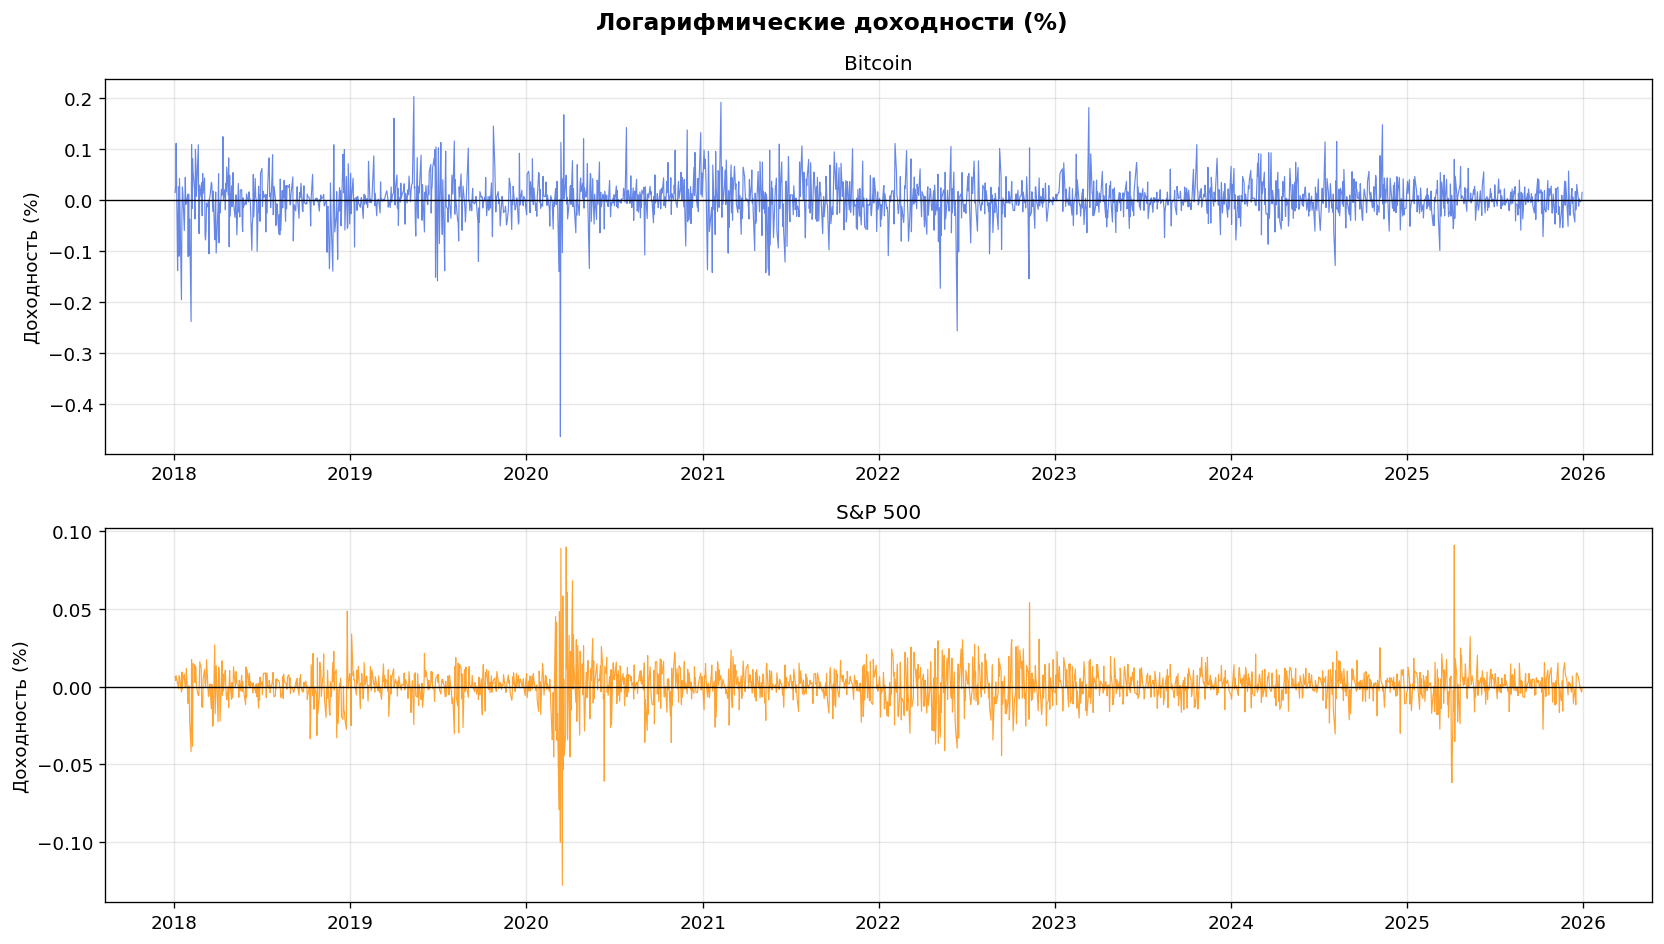

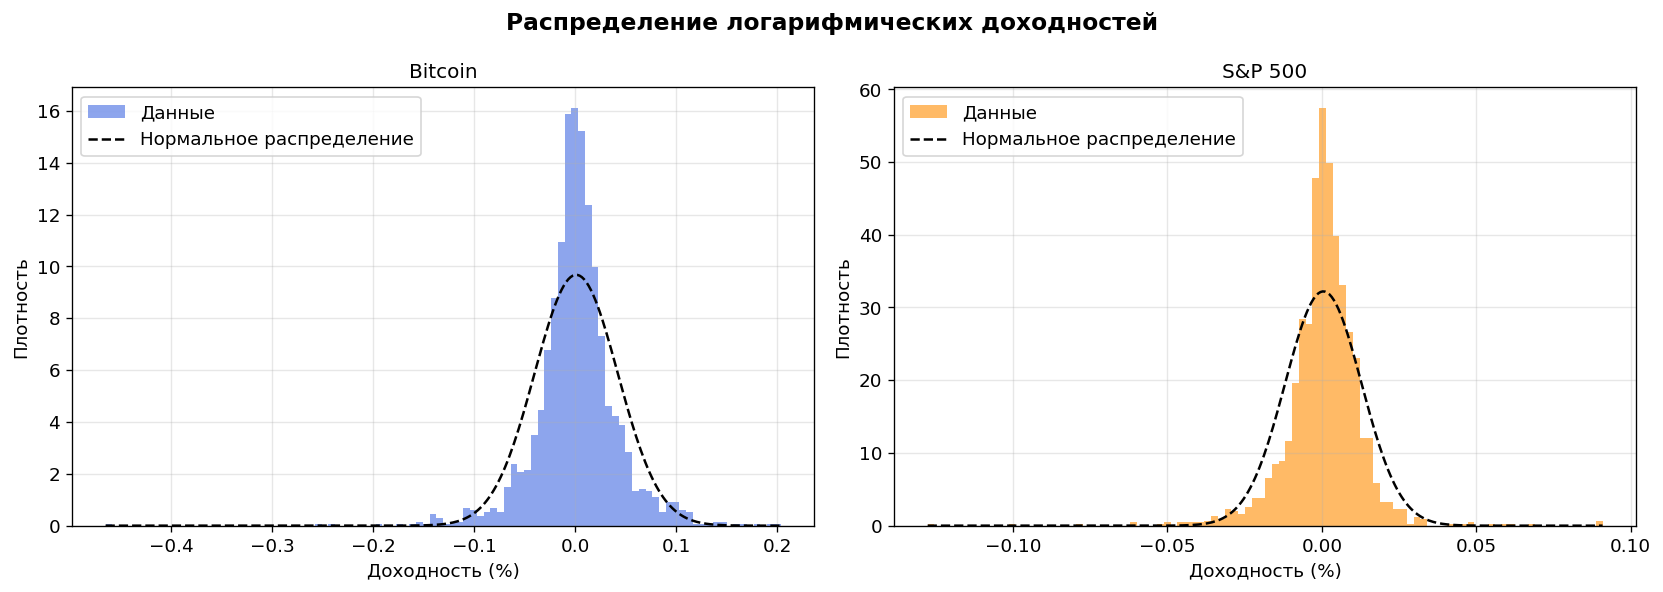

In [14]:
# Логарифмические доходности

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('Логарифмические доходности (%)', fontsize=14, fontweight='bold')

axes[0].plot(returns['BTC-USD'], color='royalblue', linewidth=0.7, alpha=0.8)
axes[0].set_title('Bitcoin', fontsize=12)
axes[0].set_ylabel('Доходность (%)')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].grid(True, alpha=0.3)

axes[1].plot(returns['^GSPC'], color='darkorange', linewidth=0.7, alpha=0.8)
axes[1].set_title('S&P 500', fontsize=12)
axes[1].set_ylabel('Доходность (%)')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Гистограммы доходностей с наложенной нормальной кривой
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Распределение логарифмических доходностей', fontsize=14, fontweight='bold')

for ax, series, label, color in zip(
        axes,
        [returns['BTC-USD'], returns['^GSPC']],
        ['Bitcoin', 'S&P 500'],
        ['royalblue', 'darkorange']):

    ax.hist(series, bins=100, density=True, color=color, alpha=0.6, label='Данные')

    # Нормальная кривая для сравнения
    x = np.linspace(series.min(), series.max(), 300)
    ax.plot(x, stats.norm.pdf(x, series.mean(), series.std()),
            'k--', linewidth=1.5, label='Нормальное распределение')

    ax.set_title(label, fontsize=12)
    ax.set_xlabel('Доходность (%)')
    ax.set_ylabel('Плотность')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
print("ПРЕДВАРИТЕЛЬНЫЙ АНАЛИЗ (обучающая выборка)")
print("=" * 80)

rows = {}
for label, series in [('BTC-USD', btc_train), ('S&P 500', sp500_train)]:
    series_clean = series.dropna().replace([np.inf, -np.inf], np.nan).dropna()

    adf_stat, adf_p, *_ = adfuller(series_clean)
    jb_stat, jb_p = stats.jarque_bera(series_clean)[:2]

    rows[label] = {
        'Ст. откл. (%)': round(series_clean.std() * 100, 2),           # 4.38
        'Годовая волатильность (%)': round(series_clean.std() * np.sqrt(252) * 100, 0),  # 70
        'Минимум (%)': round(series_clean.min() * 100, 2),
        'Максимум (%)': round(series_clean.max() * 100, 2),
        'Асимметрия': round(series_clean.skew(), 4),
        'Эксцесс': round(series_clean.kurtosis(), 4),
        'ADF p-value': round(adf_p, 4),
        'Стационарность': 'ДА' if adf_p < 0.05 else 'НЕТ',
        'JB p-value': round(jb_p, 4),
        'Нормальность': 'НЕТ' if jb_p < 0.05 else 'ДА',
    }

analysis_df = pd.DataFrame(rows).T
print(analysis_df.to_string())

ПРЕДВАРИТЕЛЬНЫЙ АНАЛИЗ (обучающая выборка)
        Ст. откл. (%) Годовая волатильность (%) Минимум (%) Максимум (%) Асимметрия  Эксцесс ADF p-value Стационарность JB p-value Нормальность
BTC-USD          4.38                      70.0      -46.47         20.3    -0.9877  10.9572         0.0             ДА        0.0          НЕТ
S&P 500          1.28                      20.0      -12.77         8.97     -0.807  14.2117         0.0             ДА        0.0          НЕТ
